# Olist E-commerce Orders Analysis
In this notebook, we explore the Olist Orders dataset, perform data cleaning, time series resampling, and visualize the macro growth trend.

In [16]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset
Loading the orders data into a Pandas DataFrame and inspecting its initial structure to understand its shape and missing values.

In [2]:
df = pd.read_csv('data/olist_orders_dataset.csv')


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


## 2. Data Cleaning & Preprocessing
Convert the timestamp columns from string objects to proper pandas datetime objects. Then, set the desired customer delivery date as the index to enable time-series resampling.

In [4]:
cols = df.columns[[3,4,5,6,7]]
df[cols] = df[cols].apply(pd.to_datetime)
df.set_index('order_delivered_customer_date',inplace = True )

In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 99441 entries, 2017-10-10 21:25:13 to 2018-03-16 13:08:30
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](4), str(3)
memory usage: 6.1 MB


## 3. Weekly Aggregation
We resample our time-series data to a weekly frequency (`'W'`). The `count()` function will give us the transaction volume per week.

In [6]:
weekly_sales = df.resample('W').count()

In [7]:
weekly_sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date
order_delivered_customer_date,,,,,,,
2016-10-16,57,57,57,57,57,57,57
2016-10-23,61,61,61,61,61,61,61
2016-10-30,69,69,69,69,69,69,69
2016-11-06,39,39,39,39,39,39,39
2016-11-13,21,21,21,21,21,21,21


## 4. Feature Selection & Feature Engineering
Select the target column that holds the count (which we'll rename to `total_orders`). We will also generate a `lag_1` feature to represent the previous week's order count, which is useful for predictive modeling.

In [8]:
weekly_sales = weekly_sales[['order_status']]

In [13]:
weekly_sales.rename(columns = {'order_status': 'total_orders'}, inplace = True)

In [15]:
weekly_sales['lag_1'] =weekly_sales['total_orders'].shift(1)
weekly_sales.dropna(inplace = True)
weekly_sales.head()

,total_orders,lag_1
order_delivered_customer_date,,
2016-10-23,61,57.0
2016-10-30,69,61.0
2016-11-06,39,69.0
2016-11-13,21,39.0
2016-11-20,14,21.0


## 5. Visualizing the Macro Trend
Finally, let's plot the raw weekly orders alongside a 4-week smoothed moving average to identify the overarching business growth trajectory.

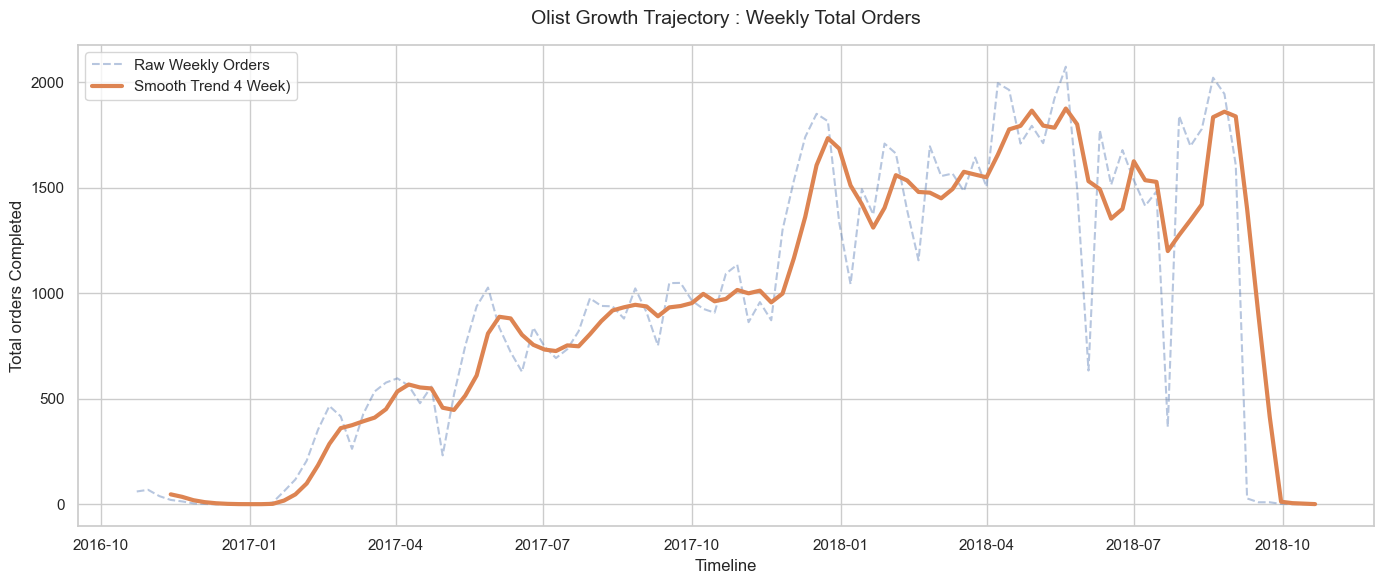

In [21]:
sns.set_theme(style = 'whitegrid')
#Macro Trend (is buisness growing)
plt.figure(figsize =(14,6))
plt.plot(weekly_sales.index, weekly_sales['total_orders'],label = 'Raw Weekly Orders', alpha =0.4, linestyle = '--')
plt.plot(weekly_sales.index, weekly_sales['total_orders'].rolling(4).mean(),label= 'Smooth Trend 4 Week)',linewidth = 3)
plt.title('Olist Growth Trajectory : Weekly Total Orders', fontsize = 14 , pad = 15)
plt.xlabel('Timeline', fontsize =12)
plt.ylabel('Total orders Completed' , fontsize = 12)
plt.legend(fontsize = 11)
plt.tight_layout()
plt.show()

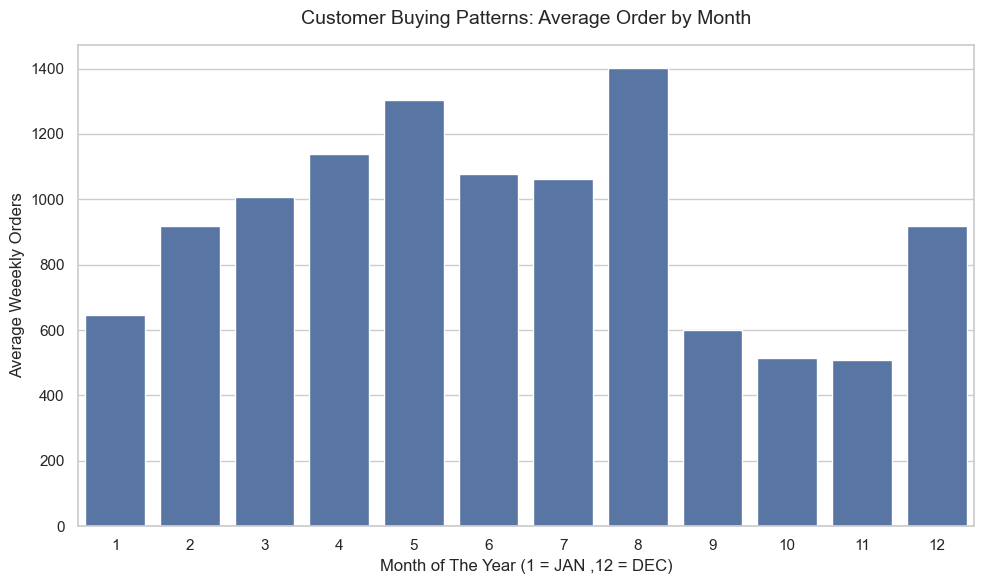

In [29]:
#Plot 2 Seasonality 
weekly_sales['month'] = weekly_sales.index.month
plt.figure(figsize = (10,6))
sns.barplot(data = weekly_sales.reset_index(), x = 'month', y = 'total_orders',estimator='mean', errorbar=None)
plt.title('Customer Buying Patterns: Average Order by Month', fontsize = 14, pad = 15)
plt.xlabel('Month of The Year (1 = JAN ,12 = DEC)',fontsize = 12)
plt.ylabel('Average Weeekly Orders', fontsize = 12)
plt.tight_layout()
plt.show()